
# REINFORCE + Baseline

Use this notebook to train the `ReinforceBaselineAgent` against multiple environments.


In [112]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Any, Callable
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from algorithms.reinforce_baseline.agent import ReinforceBaselineAgent, ReinforceAgentConfig
from mdp.gridworld.gridworld import GridWorldMDP
from mdp.cats_v_monsters.cats_vs_monsters import CatsVMonstersMDP
from mdp.cartpole.cartpole import CartPoleMDP
from mdp.mountaincar.mountaincar import MountainCarMDP

plt.style.use('ggplot')

@dataclass
class EnvSpec:
    name: str
    builder: Callable[[], Any]
    episodes: int
    max_steps: int
    description: str
    ft_builder: Callable[[Any], tuple[Callable[[Any], np.ndarray], int]] | None = None
    valft_builder: Callable[[Any], tuple[Callable[[Any], np.ndarray], int]] | None = None
    state_builder: Callable[[Any], list[Any]] | None = None
    save_policy: bool = True

In [ ]:
def _mc_feature(env):
    """Feature builder for MountainCar's continuous state space."""
    obs = env.env.observation_space
    l = np.asarray(obs.low, dtype=np.float64)
    h = np.asarray(obs.high, dtype=np.float64)
    r = np.where(h - l == 0, 1.0, h - l)

    def feature_fn(state):
        """Feature function for MountainCar's continuous state space."""
        a = np.asarray(state, dtype=np.float64)
        n = (a - l) / r * 2.0 - 1.0
        p, v = n
        a_0 = a[0]
        return np.array(
            [
                1.0,
                p,
                v,
                p * v,
                p**2,
                v**2,
                np.sin(3.0 * a_0),
                np.cos(3.0 * a_0),
            ],
            dtype=np.float64,
        )

    return feature_fn, 8

def _mountaincar_state_grid(env, *, pos_bins=40, vel_bins=40):
    """Returns discrete MountainCar states for policy inspection."""
    obs_space = env.env.observation_space
    pos_vals = np.linspace(obs_space.low[0], obs_space.high[0], pos_bins)
    vel_vals = np.linspace(obs_space.low[1], obs_space.high[1], vel_bins)
    return [(float(p), float(v)) for p in pos_vals for v in vel_vals]


def _cartpole_feature(env):
    """Feature builder for CartPole's continuous state space."""
    clip_low = np.array([-4.8, -5.0, -0.418, -5.0], dtype=np.float64)
    clip_high = np.array([4.8, 5.0, 0.418, 5.0], dtype=np.float64)
    scale = np.where(clip_high - clip_low == 0, 1.0, clip_high - clip_low)

    def feature_fn(state):
        a = np.asarray(state, dtype=np.float64)
        a = np.clip(a, clip_low, clip_high)
        n = (a - clip_low) / scale * 2.0 - 1.0
        x, x_dot, theta, theta_dot = n
        return np.array(
            [
                1.0,
                x,
                x_dot,
                theta,
                theta_dot,
                x * theta,
                x_dot * theta_dot,
                theta * theta_dot,
                theta**2,
                theta_dot**2,
            ],
            dtype=np.float64,
        )

    return feature_fn, 10


In [132]:
ENV_REGISTRY = {
    'gridworld': EnvSpec(
        name='GridWorld 5x5',
        builder=lambda: GridWorldMDP(rows=5, cols=5),
        episodes=1000,
        max_steps=150,
        description='5x5 grid with goal at (4, 4).'
    ),
    'cats_vs_monsters': EnvSpec(
        name='Cats vs Monsters',
        builder=lambda: CatsVMonstersMDP(rows=5, cols=5),
        episodes=1000,
        max_steps=150,
        description='MDP with monsters and food rewards.'
    ),
    'cartpole': EnvSpec(
        name='CartPole-v1',
        builder=lambda: CartPoleMDP(seed=42),
        episodes=1500, #3000
        max_steps=500, #3000
        description='Classic CartPole balancing with continuous observations.',
        ft_builder=_cartpole_feature,
        valft_builder=_cartpole_feature,
        save_policy=False,
    ),
    'mountaincar': EnvSpec(
        name='MountainCar-v0',
        builder=lambda: MountainCarMDP(seed=42),
        episodes=3000,
        max_steps=200,
        description='Classic MountainCar control task with continuous state.',
        ft_builder=_mc_feature,
        valft_builder=_mc_feature,
        state_builder=lambda env: _mountaincar_state_grid(env, pos_bins=40, vel_bins=40),
        save_policy=True,
    ),
}

print('Available environments:')
for key,spec in ENV_REGISTRY.items():
    print(f"  - {key} : {spec.description}")


Available environments:
  - gridworld : 5x5 grid with goal at (4, 4).
  - cats_vs_monsters : MDP with monsters and food rewards.
  - cartpole : Classic CartPole balancing with continuous observations.
  - mountaincar : Classic MountainCar control task with continuous state.


In [115]:
BASE_AGENT_CONFIG_cp = ReinforceAgentConfig(
    gamma=0.99,
    alpha_theta=0.006,  # was 0.003; higher policy step for faster improvement
    alpha_w=0.01,      # was 0.02; smaller value step to stabilize baseline
    use_baseline=True,
    seed=42,
)
BASE_AGENT_CONFIG = ReinforceAgentConfig(
    gamma=0.99,
    alpha_theta=0.003,  # was 0.003; higher policy step for faster improvement
    alpha_w=0.02,      # was 0.02; smaller value step to stabilize baseline
    use_baseline=True,
    seed=42,
)



In [116]:
results = {}


In [117]:
def get_state_space(env):
    """Return the environment's valid state space."""
    if hasattr(env, 'get_state_space'):
        states = list(env.get_state_space())
        if states:
            return states
    raise ValueError('Environment must implement get_state_space().')
    
def _make_feature_func(states):
    """Return a callable that maps states to one-hot feature vectors."""

    def to_key(state):
        if state is None:
            return None
        if isinstance(state, tuple):
            return state
        if isinstance(state, list):
            return tuple(state)
        if hasattr(state, "tolist"):
            return tuple(state.tolist())
        return state

    normalized_states = [to_key(state) for state in states]
    state_to_index = {state: i for i, state in enumerate(normalized_states)}
    feature_dim = len(state_to_index)

    def feature_fn(state):
        vector = np.zeros(feature_dim, dtype=np.float64)
        i = state_to_index.get(to_key(state))
        if i is not None:
            vector[i] = 1.0
        return vector

    return feature_fn, feature_dim


def _get_action_space(env):
    if hasattr(env, "get_action_space"):
        space = env.get_action_space()
        try:
            return list(space)
        except TypeError:
            if hasattr(space, "n"):
                return list(range(int(space.n)))
        if hasattr(space, "shape") and space.shape:
            raise ValueError("Continuous action spaces are not supported.")
        raise TypeError("Unsupported action space type")
    raise AttributeError("Environment must provide get_action_space() or action_space.")


def _format_policy_grid(state_list, best_action_map):
    tuple_states = [
        state
        for state in state_list
        if isinstance(state, tuple)
        and len(state) == 2
        and all(isinstance(x, int) for x in state)
    ]
    if not tuple_states:
        return None

    max_r = max(r for r, _ in tuple_states)
    max_c = max(c for _, c in tuple_states)
    grid = [["·" for _ in range(max_c + 1)] for _ in range(max_r + 1)]
    arrow_map = {
        "up": "↑",
        "down": "↓",
        "left": "←",
        "right": "→",
    }
    for state in tuple_states:
        r, c = state
        action = best_action_map.get(state)
        grid[r][c] = arrow_map.get(action, action or "·")

    lines = ["Policy grid (rows top→bottom, cols left→right):"]
    for row in grid:
        lines.append(" ".join(row))
    return "\n".join(lines)


def _save_policy(agent, env_key, policy_dir, state_list, feature_fn):
    policy_dir = Path(policy_dir)
    policy_dir.mkdir(parents=True, exist_ok=True)
    policy_path = policy_dir / f"{env_key}_policy_baseline.npz"
    metadata = {
        "env_key": env_key,
        "feature_dim": int(agent.policy.theta.shape[1]) if agent.policy.theta is not None else 0,
    }
    np.savez(
        policy_path,
        theta=agent.policy.theta,
        actions=np.asarray(agent.policy.actions, dtype=object),
        state_list=np.asarray(state_list, dtype=object),
        metadata=json.dumps(metadata),
    )

    pretty_lines = [
        f"Policy snapshot for {env_key}",
        "Format: state -> best action | action probabilities",
        "",
    ]
    best_action_map = {}
    for state in state_list:
        features = feature_fn(state)
        probs = agent.policy.probs(features)
        best_i = int(np.argmax(probs))
        best_action = agent.policy.actions[best_i]
        best_action_map[state] = best_action
        probs_str = ", ".join(
            f"{action}:{prob:.3f}" for action, prob in zip(agent.policy.actions, probs)
        )
        pretty_lines.append(
            f"state={state}: best={best_action} ({probs[best_i]:.3f}) | probs: {probs_str}"
        )

    grid_repr = _format_policy_grid(state_list, best_action_map)
    if grid_repr:
        pretty_lines.extend(["", grid_repr])

    text_path = policy_path.with_suffix(".txt")
    text_path.write_text("\n".join(pretty_lines) + "\n", encoding="utf-8")
    return {"weights": policy_path, "text": text_path}


def run_reinforce_experiment(
    env_key,
    *,
    episodes=None,
    max_steps=None,
    agent_config=None,
    log_dir=Path("reinforce_logs"),
    save_policy=True,
    policy_dir=Path("policies"),
):
    """Train a ReinforceBaselineAgent on the environment and report diagnostics."""
    if env_key not in ENV_REGISTRY:
        raise KeyError(f"Unknown environment key: {env_key!r}")

    spec = ENV_REGISTRY[env_key]
    env = spec.builder()
    state_list = spec.state_builder(env) if spec.state_builder else None

    if spec.ft_builder:
        policy_features, feature_dim = spec.ft_builder(env)
    else:
        if state_list is None:
            state_list = get_state_space(env)
        policy_features, feature_dim = _make_feature_func(state_list)

    if spec.valft_builder:
        value_features, _ = spec.valft_builder(env)
    else:
        value_features = policy_features

    action_space = _get_action_space(env)
    episodes = episodes or spec.episodes
    max_steps = max_steps or spec.max_steps

    state_label = len(state_list) if state_list is not None else 'continuous'
    print(f"\n=== {spec.name} ({env_key}) ===")
    print(f"      States: {state_label}, Actions: {len(action_space)}, Feature dim: {feature_dim}")
    print(f"      Episodes: {episodes}, Max steps/episode: {max_steps}")

    agent = ReinforceBaselineAgent(
        action_space,
        policy_feature_fn=policy_features,
        value_feature_fn=value_features,
        config=agent_config,
    )
    stats, episode_logs = agent.train(env, episodes=episodes, max_steps=max_steps)

    log_dir = Path(log_dir)
    log_dir.mkdir(parents=True, exist_ok=True)
    log_path = log_dir / f"{env_key}_episodes.json"
    payload = {
        "environment_key": env_key,
        "environment_name": spec.name,
        "description": spec.description,
        "episodes": episodes,
        "max_steps": max_steps,
        "logs": episode_logs,
    }
    with log_path.open("w", encoding="utf-8") as fh:
        json.dump(payload, fh, indent=2)
    print(f"      Saved {len(episode_logs)} episode logs to {log_path}")
    policy_artifacts = None

    should_save_policy = save_policy and spec.save_policy and state_list is not None
    if should_save_policy:
        policy_artifacts = _save_policy(
            agent,
            env_key,
            policy_dir,
            state_list,
            policy_features,
        )
        print(f"      Saved policy to {policy_artifacts['text']}")
    elif save_policy and spec.save_policy and state_list is None:
        print("      Policy export skipped (no discrete state listing).")

    returns = [stat.episode_return for stat in stats]
    lengths = [stat.length for stat in stats]
    success_flags = [stat.success for stat in stats]
    positive_counts = [stat.positive_rewards for stat in stats]
    penalty_counts = [stat.penalty_rewards for stat in stats]
    baseline_mse_values = [stat.baseline_mse for stat in stats]

    success_rate = float(np.mean(success_flags)) if success_flags else 0.0
    avg_positive = float(np.mean(positive_counts)) if positive_counts else 0.0
    avg_penalty = float(np.mean(penalty_counts)) if penalty_counts else 0.0
    avg_baseline_mse = float(np.mean(baseline_mse_values)) if baseline_mse_values else 0.0

    print(f"      Success rate: {success_rate * 100:.1f}%")
    print(
        f"      Avg reward components → positive: {avg_positive:.1f}, penalties: {avg_penalty:.1f}"
    )
    print(f"      Avg baseline MSE: {avg_baseline_mse:.4f}")

    return {
        "environment_key": env_key,
        "environment_name": spec.name,
        "description": spec.description,
        "episodes": episodes,
        "max_steps": max_steps,
        "feature_dim": feature_dim,
        "state_space_size": len(state_list) if state_list is not None else None,
        "returns": returns,
        "lengths": lengths,
        "success_flags": success_flags,
        "positive_counts": positive_counts,
        "penalty_counts": penalty_counts,
        "baseline_mse": baseline_mse_values,
        "success_rate": success_rate,
        "avg_positive_rewards": avg_positive,
        "avg_penalty_rewards": avg_penalty,
        "avg_baseline_mse": avg_baseline_mse,
        "log_path": str(log_path),
        "policy_paths": {
            "weights": str(policy_artifacts["weights"]) if policy_artifacts else None,
            "text": str(policy_artifacts["text"]) if policy_artifacts else None,
        },
    }


In [118]:
def plot_episode_returns(result_map, *, rolling_window=20, ax=None):
    """Plot raw and smoothed episode returns for one or more experiments."""
    if not result_map:
        raise ValueError("result_map must contain at least one experiment payload.")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    else:
        fig = ax.figure

    for label, payload in result_map.items():
        returns = np.asarray(payload.get('returns', []), dtype=np.float64)
        if returns.size == 0:
            continue
        episodes = np.arange(1, returns.size + 1)
        ax.plot(episodes, returns, alpha=0.3, label=f"{label} (raw)")

        window = max(1, min(rolling_window, returns.size))
        kernel = np.ones(window) / window
        smoothed = np.convolve(returns, kernel, mode='valid')
        smoothed_x = episodes[window - 1:]
        ax.plot(smoothed_x, smoothed, label=f"{label} ({window}-ep avg)")

    ax.set_title('Episode returns')
    ax.set_xlabel('Episode #')
    ax.set_ylabel('Return')
    ax.legend(loc='best')
    ax.grid(True)
    fig.tight_layout()
    return ax


In [119]:
def _line_plot(metric_map, *, label_suffix, ylabel, rolling_window=20, ax=None, title=None):
    """Utility to plot raw and smoothed metrics stored as per-episode lists."""
    if not metric_map:
        raise ValueError("metric_map must contain at least one experiment payload.")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    else:
        fig = ax.figure

    color_cycle = plt.get_cmap('tab10')
    for i, (label, values) in enumerate(metric_map.items()):
        data = np.asarray(values, dtype=np.float64)
        if data.size == 0:
            continue
        color = color_cycle(i % 10)
        episodes = np.arange(1, data.size + 1)
        ax.plot(
            episodes,
            data,
            alpha=0.7,
            color=color,
            linestyle='--',
            linewidth=1.5,
            label=f"{label} (raw {label_suffix})",
        )

        window = max(1, min(rolling_window, data.size))
        kernel = np.ones(window) / window
        smoothed = np.convolve(data, kernel, mode='valid')
        smoothed_x = episodes[window - 1:]
        ax.plot(
            smoothed_x,
            smoothed,
            color=color,
            linewidth=2.5,
            label=f"{label} ({window}-ep avg {label_suffix})",
        )

    ax.set_xlabel('Episode #')
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.legend(loc='best')
    ax.grid(True)
    fig.tight_layout()
    return ax


def _prepare_env_axes(result_map):
    env_items = list(result_map.items())
    if not env_items:
        raise ValueError("result_map must contain at least one experiment payload.")
    fig, axes = plt.subplots(len(env_items), 1, figsize=(8, 4 * len(env_items)), sharex=False)
    if len(env_items) == 1:
        axes = [axes]
    return env_items, fig, axes


def plot_reward_components(result_map, *, rolling_window=20):
    """Plot positive vs penalty reward counts per episode for each environment."""
    env_items, fig, axes = _prepare_env_axes(result_map)
    for ax, (label, payload) in zip(axes, env_items):
        metric_map = {
            f"{label} (+)": np.asarray(payload.get('positive_counts', []), dtype=np.float64),
            f"{label} (penalty)": np.asarray(payload.get('penalty_counts', []), dtype=np.float64),
        }
        _line_plot(
            metric_map,
            label_suffix='rewards',
            ylabel='# rewards / episode',
            rolling_window=rolling_window,
            ax=ax,
            title=f"{label}: reward components",
        )
    fig.tight_layout()
    return axes


def plot_success_rate(result_map, *, rolling_window=20):
    """Plot success indicators per environment with smoothing to show success rate."""
    env_items, fig, axes = _prepare_env_axes(result_map)
    for ax, (label, payload) in zip(axes, env_items):
        metric_map = {
            label: np.asarray(payload.get('success_flags', []), dtype=np.float64)
        }
        _line_plot(
            metric_map,
            label_suffix='success',
            ylabel='Success rate',
            rolling_window=rolling_window,
            ax=ax,
            title=f"{label}: success trajectory",
        )
        ax.set_ylim(-0.05, 1.05)
    fig.tight_layout()
    return axes


def plot_baseline_mse(result_map, *, rolling_window=20):
    """Plot per-episode baseline mean-squared error for each environment."""
    env_items, fig, axes = _prepare_env_axes(result_map)
    for ax, (label, payload) in zip(axes, env_items):
        metric_map = {
            label: np.asarray(payload.get('baseline_mse', []), dtype=np.float64)
        }
        _line_plot(
            metric_map,
            label_suffix='baseline MSE',
            ylabel='Baseline MSE',
            rolling_window=rolling_window,
            ax=ax,
            title=f"{label}: baseline MSE",
        )
    fig.tight_layout()
    return axes


## GridWorld 5x5 experiment
Run REINFORCE with baseline on the stochastic GridWorld map.


=== GridWorld 5x5 (gridworld) ===
      States: 25, Actions: 4, Feature dim: 25
      Episodes: 1000, Max steps/episode: 150
      Saved 1000 episode logs to reinforce_logs/gridworld_episodes.json
      Saved policy to policies/gridworld_policy_baseline.txt
      Success rate: 96.5%
      Avg reward components → positive: 1.0, penalties: 0.2
      Avg baseline MSE: 24.4345


{'environment_key': 'gridworld',
 'environment_name': 'GridWorld 5x5',
 'description': '5x5 grid with goal at (4, 4).',
 'episodes': 1000,
 'max_steps': 150,
 'feature_dim': 25,
 'state_space_size': 25,
 'returns': [6.622820409839836,
  -2.938515791626047,
  5.048858887870697,
  -51.98169486036483,
  -0.26592441489738144,
  4.5204365026647535,
  -17.01994989130555,
  -10.719566643439121,
  -8.10926522309594,
  -8.9584115802767,
  6.426116020847182,
  -14.702858482702736,
  -4.696912108735298,
  -10.52139065696706,
  -3.7639912546656378,
  -51.65865938784246,
  4.386175018099108,
  3.37754400898902,
  -14.643870740822983,
  -7.647261190862097,
  -2.6804671691687414,
  2.9048849430996384,
  -19.04549475383437,
  -48.08338455664694,
  6.757290490602832,
  2.549097606963093,
  3.5160920655802226,
  0.0,
  6.172901409422881,
  0.0,
  6.491026283684023,
  0.0,
  7.936142836436555,
  -0.15634995002063648,
  -8.21769845556438,
  4.849913702741629,
  4.298890135238936,
  3.024044356690216,
  4.

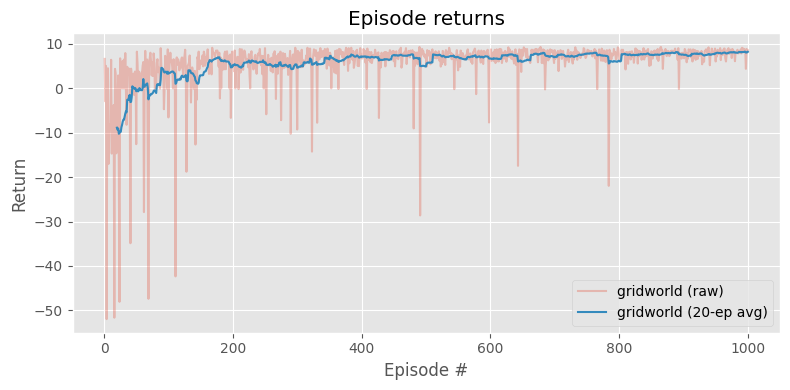

In [120]:
gridworld_result = run_reinforce_experiment('gridworld', agent_config=BASE_AGENT_CONFIG)
results['gridworld'] = gridworld_result
plot_episode_returns({'gridworld': gridworld_result})

gridworld_result


## Cats vs Monsters experiment
Run REINFORCE with baseline on the Cats vs Monsters grid.


=== Cats vs Monsters (cats_vs_monsters) ===
      States: 25, Actions: 4, Feature dim: 25
      Episodes: 1000, Max steps/episode: 150
      Saved 1000 episode logs to reinforce_logs/cats_vs_monsters_episodes.json
      Saved policy to policies/cats_vs_monsters_policy_baseline.txt
      Success rate: 96.6%
      Avg reward components → positive: 1.0, penalties: 41.1
      Avg baseline MSE: 84.5536


{'environment_key': 'cats_vs_monsters',
 'environment_name': 'Cats vs Monsters',
 'description': 'MDP with monsters and food rewards.',
 'episodes': 1000,
 'max_steps': 150,
 'feature_dim': 25,
 'state_space_size': 25,
 'returns': [-32.977429562830324,
  -2.7168911887003246,
  -72.46215751527862,
  -24.343228719469018,
  -46.75676226927761,
  -18.929004768751476,
  -36.87386888831138,
  -7.841969609941481,
  -35.933610928961656,
  -44.74251427266469,
  -22.29756081162631,
  -88.2472181753232,
  0.3361736951619157,
  -3.6023000546238384,
  -78.0957525236432,
  -61.20103968532414,
  -16.724977517942154,
  -113.21417043744906,
  -37.994451268396325,
  -51.0778567131991,
  -6.811334921753395,
  -42.8157159895629,
  -39.484532131623126,
  -34.02527542466628,
  -7.3170558492286455,
  -52.99951442271667,
  -6.900515066932384,
  -8.761212888512809,
  -24.778641192704526,
  -1.085274888465753,
  -29.376328955719842,
  -25.705178943348148,
  -48.449633612018,
  7.392529357533792,
  -21.352700981

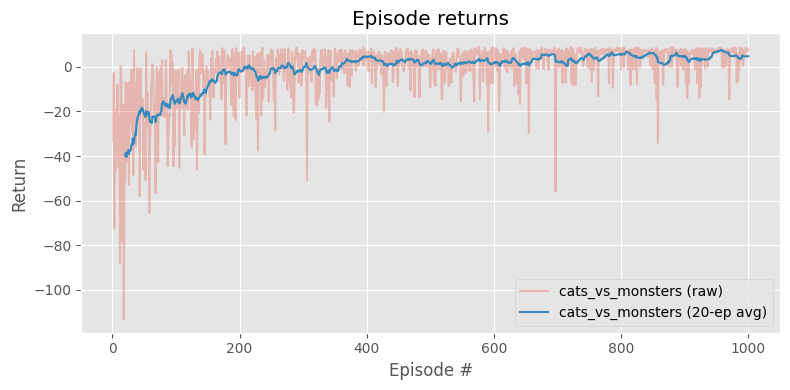

In [121]:
cats_vs_monsters_result = run_reinforce_experiment('cats_vs_monsters', agent_config=BASE_AGENT_CONFIG)
results['cats_vs_monsters'] = cats_vs_monsters_result
plot_episode_returns({'cats_vs_monsters': cats_vs_monsters_result})

cats_vs_monsters_result


## MountainCar experiment
Train REINFORCE with learned baseline on the continuous-state MountainCar control task.


=== MountainCar-v0 (mountaincar) ===
      States: 1600, Actions: 3, Feature dim: 8
      Episodes: 3000, Max steps/episode: 200
      Saved 3000 episode logs to reinforce_logs/mountaincar_episodes.json
      Saved policy to policies/mountaincar_policy_baseline.txt
      Success rate: 100.0%
      Avg reward components → positive: 0.0, penalties: 200.0
      Avg baseline MSE: 341.9483


{'environment_key': 'mountaincar',
 'environment_name': 'MountainCar-v0',
 'description': 'Classic MountainCar control task with continuous state.',
 'episodes': 3000,
 'max_steps': 200,
 'feature_dim': 8,
 'state_space_size': 1600,
 'returns': [-86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60203251420373,
  -86.60

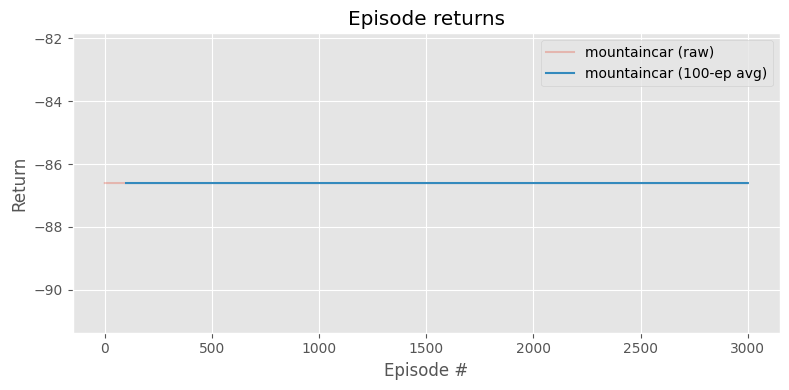

In [122]:
mountaincar_result = run_reinforce_experiment('mountaincar', agent_config=BASE_AGENT_CONFIG)
results['mountaincar'] = mountaincar_result
plot_episode_returns({'mountaincar': mountaincar_result}, rolling_window=100)

mountaincar_result

## CartPole experiment
Train REINFORCE with baseline on the classic cart-balancing control task.


=== CartPole-v1 (cartpole) ===
      States: continuous, Actions: 2, Feature dim: 10
      Episodes: 1500, Max steps/episode: 500
      Saved 1500 episode logs to reinforce_logs/cartpole_episodes.json
      Success rate: 100.0%
      Avg reward components → positive: 336.4, penalties: 0.0
      Avg baseline MSE: 305.3649


{'environment_key': 'cartpole',
 'environment_name': 'CartPole-v1',
 'description': 'Classic CartPole balancing with continuous observations.',
 'episodes': 1500,
 'max_steps': 500,
 'feature_dim': 10,
 'state_space_size': None,
 'returns': [18.209306240276913,
  14.854222890512437,
  18.209306240276913,
  13.12541872310217,
  26.02996266117195,
  11.361512828387072,
  18.209306240276913,
  13.12541872310217,
  16.54862385499124,
  18.209306240276913,
  35.08973716315975,
  14.854222890512437,
  20.638571635634445,
  10.466174574128356,
  22.995685419484467,
  26.76966303456023,
  16.54862385499124,
  14.854222890512437,
  13.994164535871148,
  21.4321859192781,
  23.76572856528962,
  20.638571635634445,
  19.027213177874142,
  16.54862385499124,
  19.8369410460954,
  30.358678195042614,
  40.70335535985003,
  12.247897700103202,
  37.01763687967674,
  13.12541872310217,
  13.994164535871148,
  11.361512828387072,
  13.994164535871148,
  11.361512828387072,
  12.247897700103202,
  44.1

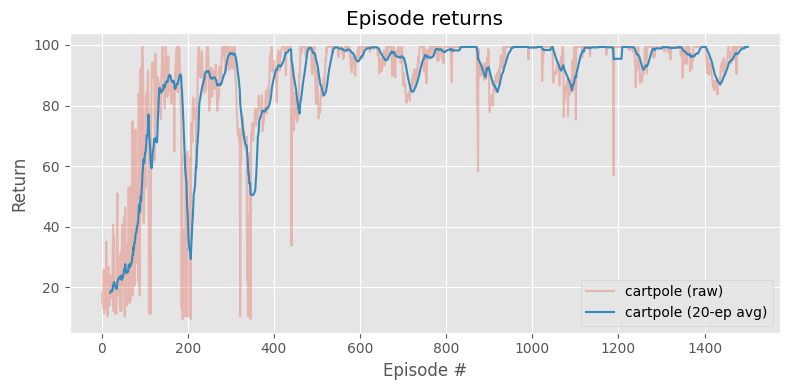

In [133]:
cartpole_result = run_reinforce_experiment('cartpole', agent_config=BASE_AGENT_CONFIG_cp)
results['cartpole'] = cartpole_result
plot_episode_returns({'cartpole': cartpole_result})

cartpole_result

### CartPole-v1 diagnostics
Additional REINFORCE diagnostics for CartPole in one place.

[<Axes: title={'center': 'cartpole: baseline MSE'}, xlabel='Episode #', ylabel='Baseline MSE'>]

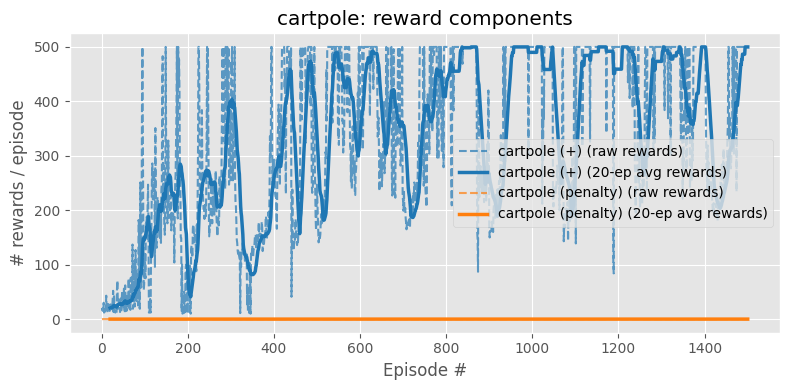

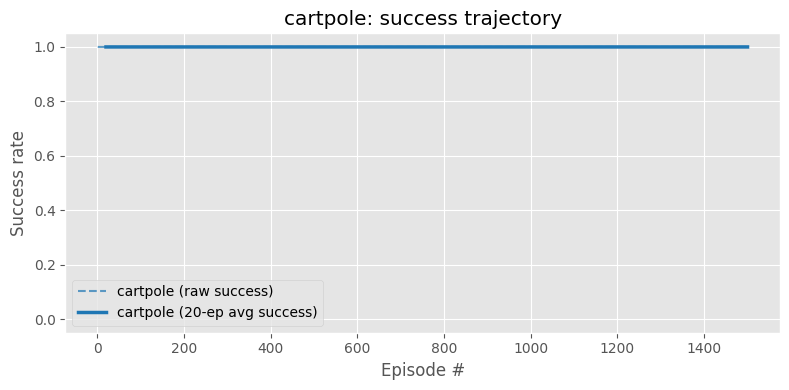

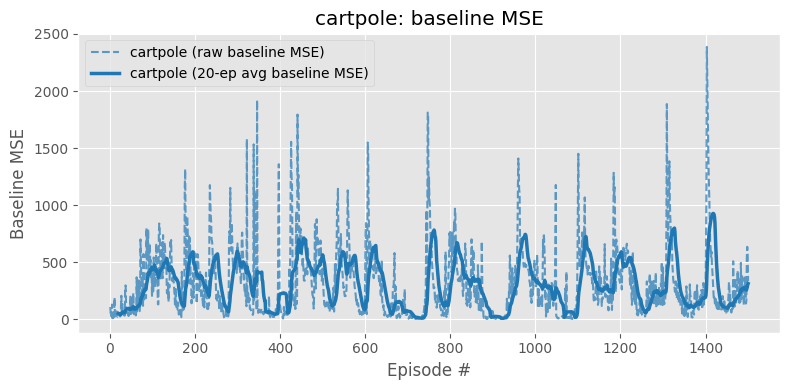

In [134]:
plot_reward_components({'cartpole': cartpole_result})
plot_success_rate({'cartpole': cartpole_result})
plot_baseline_mse({'cartpole': cartpole_result})

## Training diagnostics
Use the helpers below after running experiments to visualize success rate, reward components, and baseline MSE across episodes.

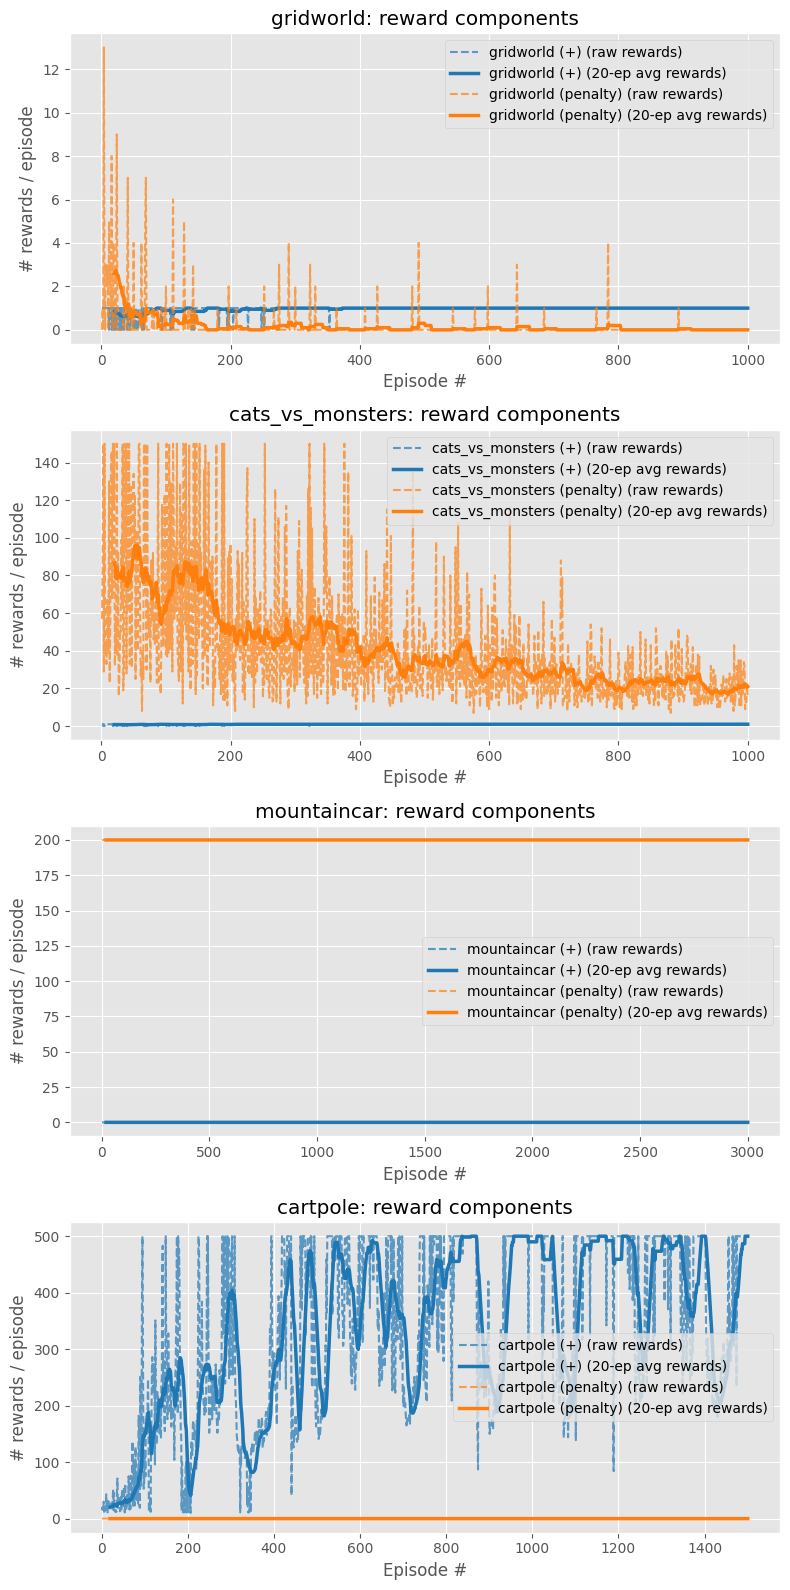

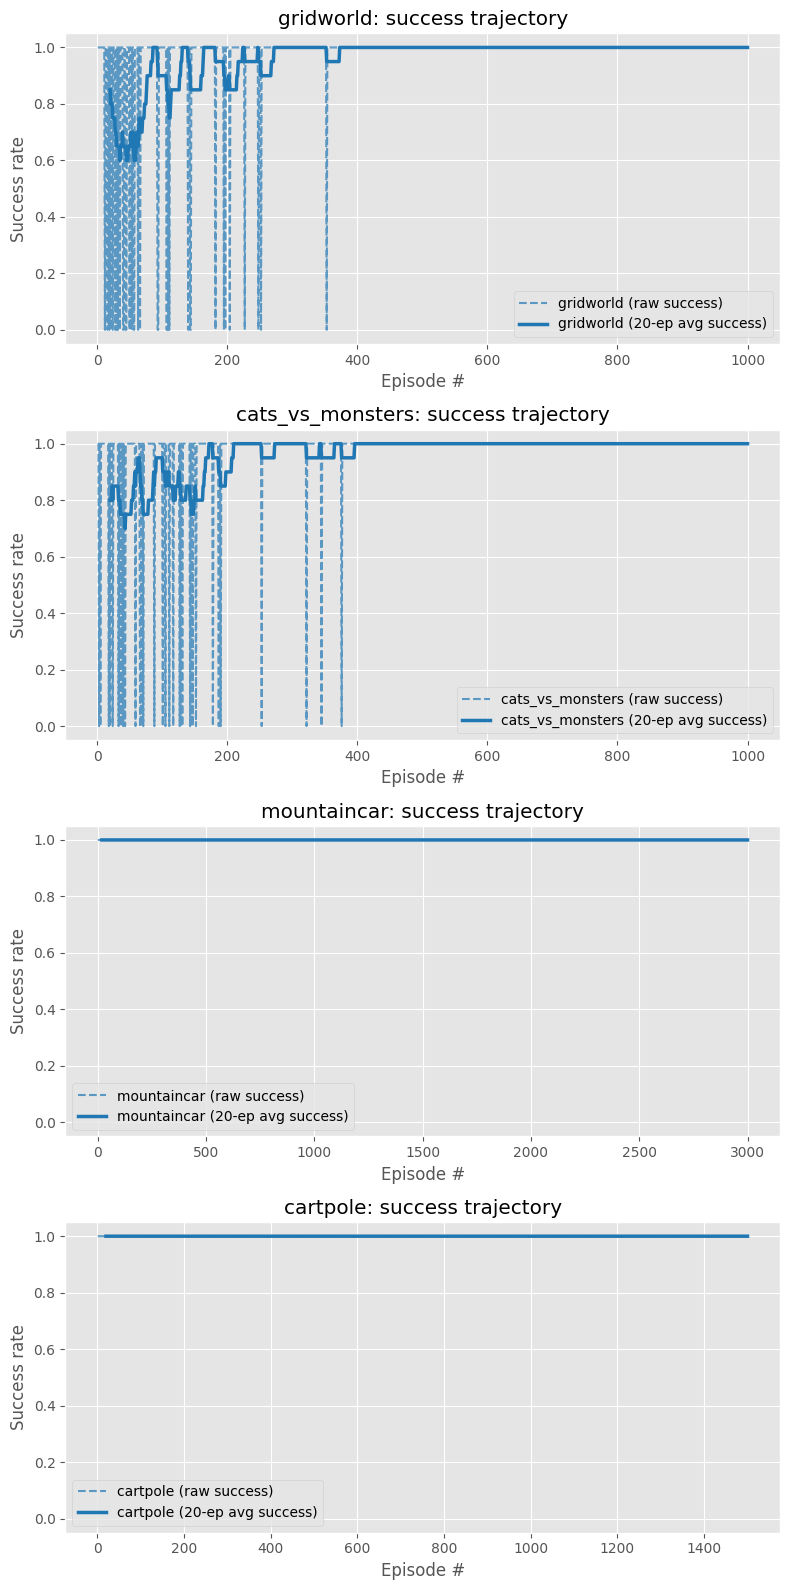

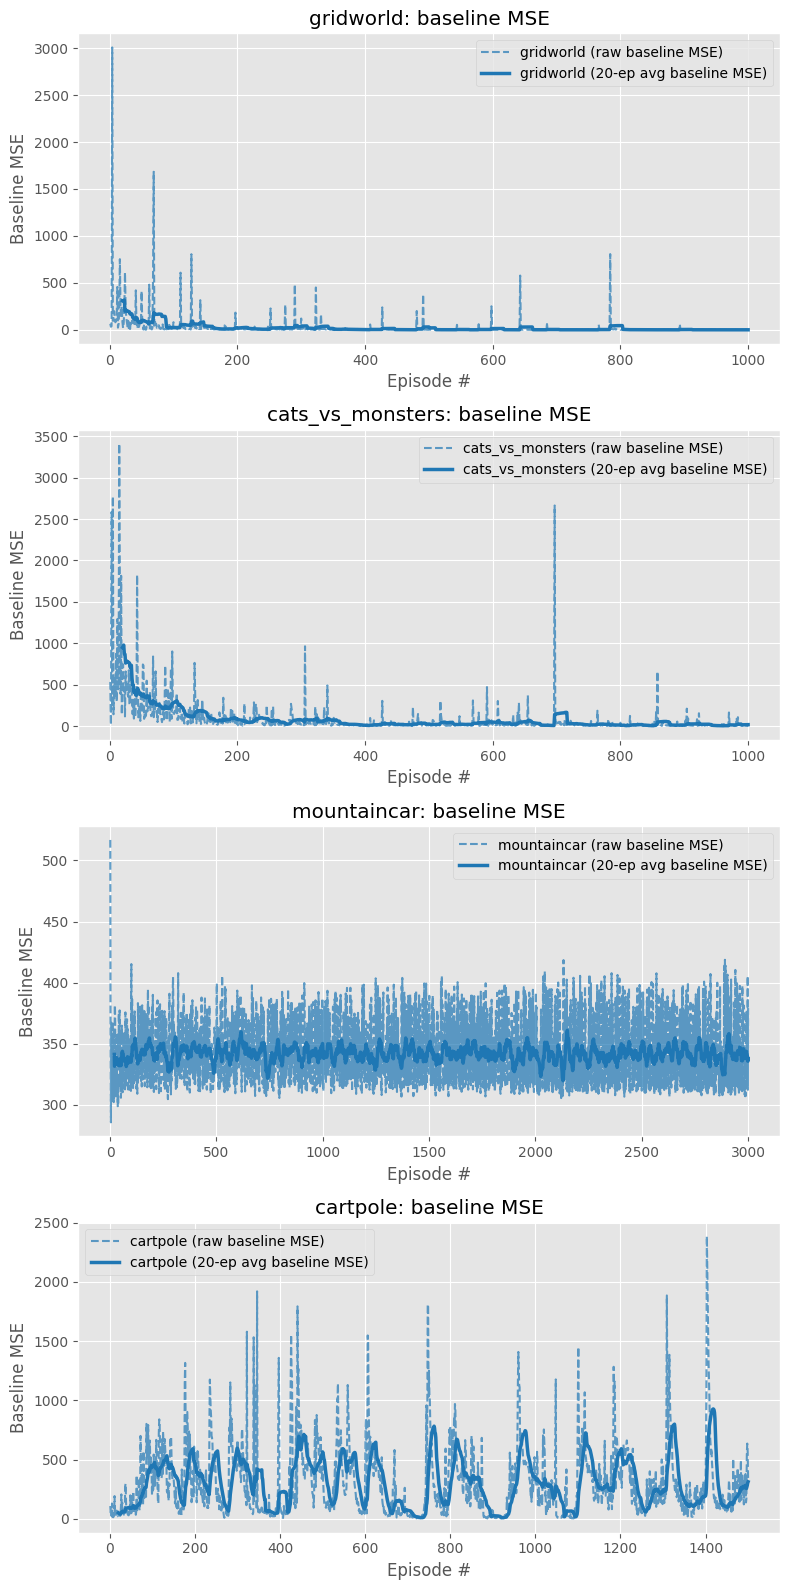

In [125]:
if results:
    plot_reward_components(results)
    plot_success_rate(results)
    plot_baseline_mse(results)
else:
    print("Run an experiment first to generate metrics.")

In [126]:

if not results:
    print('No experiments have been run yet.')
else:
    for env_name, data in results.items():
        returns = np.asarray(data['returns'], dtype=np.float64)
        lengths = np.asarray(data['lengths'], dtype=np.float64)
        success_flags = np.asarray(data.get('success_flags', []), dtype=np.float64)
        positive_counts = np.asarray(data.get('positive_counts', []), dtype=np.float64)
        penalty_counts = np.asarray(data.get('penalty_counts', []), dtype=np.float64)
        baseline_mse = np.asarray(data.get('baseline_mse', []), dtype=np.float64)

        success_rate = success_flags.mean() if success_flags.size else 0.0
        avg_positive = positive_counts.mean() if positive_counts.size else 0.0
        avg_penalty = penalty_counts.mean() if penalty_counts.size else 0.0
        avg_baseline_mse = baseline_mse.mean() if baseline_mse.size else 0.0

        print(f"{env_name}: return mean={returns.mean():.2f} +/- {returns.std():.2f}, max={returns.max():.2f}")
        print(f"           length mean={lengths.mean():.1f}, min={lengths.min():.0f}, max={lengths.max():.0f}")
        print(
            f"           success rate={success_rate * 100:.1f}% | +reward={avg_positive:.1f}, penalties={avg_penalty:.1f}"
        )
        print(f"           baseline MSE mean={avg_baseline_mse:.4f}")
        print('-' * 72)


gridworld: return mean=5.84 +/- 5.76, max=9.32
           length mean=42.9, min=8, max=150
           success rate=96.5% | +reward=1.0, penalties=0.2
           baseline MSE mean=24.4345
------------------------------------------------------------------------
cats_vs_monsters: return mean=-1.05 +/- 13.10, max=8.98
           length mean=42.1, min=8, max=150
           success rate=96.6% | +reward=1.0, penalties=41.1
           baseline MSE mean=84.5536
------------------------------------------------------------------------
mountaincar: return mean=-86.60 +/- 0.00, max=-86.60
           length mean=200.0, min=200, max=200
           success rate=100.0% | +reward=0.0, penalties=200.0
           baseline MSE mean=341.9483
------------------------------------------------------------------------
cartpole: return mean=88.07 +/- 20.62, max=99.34
           length mean=336.4, min=10, max=500
           success rate=100.0% | +reward=336.4, penalties=0.0
           baseline MSE mean=305.3649
--

In [127]:
def load_episode_log(env_key, results_dict=None):
    """Return the saved episode log payload for a recorded experiment."""
    results_dict = results_dict or results
    result = results_dict.get(env_key)
    if result is None:
        raise KeyError(f"No entry named {env_key!r} in results.")

    log_path = result.get('log_path')
    if not log_path:
        print(f"{env_key}: no log path recorded. Rerun run_reinforce_experiment to regenerate logs.")
        return None

    log_file = Path(log_path)
    if not log_file.exists():
        print(f"Log file {log_file} is missing. Rerun the experiment to recreate it.")
        return None

    with log_file.open('r', encoding='utf-8') as fh:
        payload = json.load(fh)

    print(f"Loaded {len(payload.get('logs', []))} episodes from {log_file}")
    return payload
